In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# Loading catchment streamflow data

streamflow = pd.read_csv("01013500_streamflow_qc.txt", sep=r"\s+")

# Adding column labels and a date column

streamflow.columns = ["gauge_id", "year", "month", "day", "flow", "flag"]
streamflow['date']  = pd.to_datetime(streamflow[['year', 'month', 'day']])
streamflow = streamflow.dropna()

# Creating a variable with streamflow over time

annual_flow = streamflow.groupby('year')['flow'].mean()

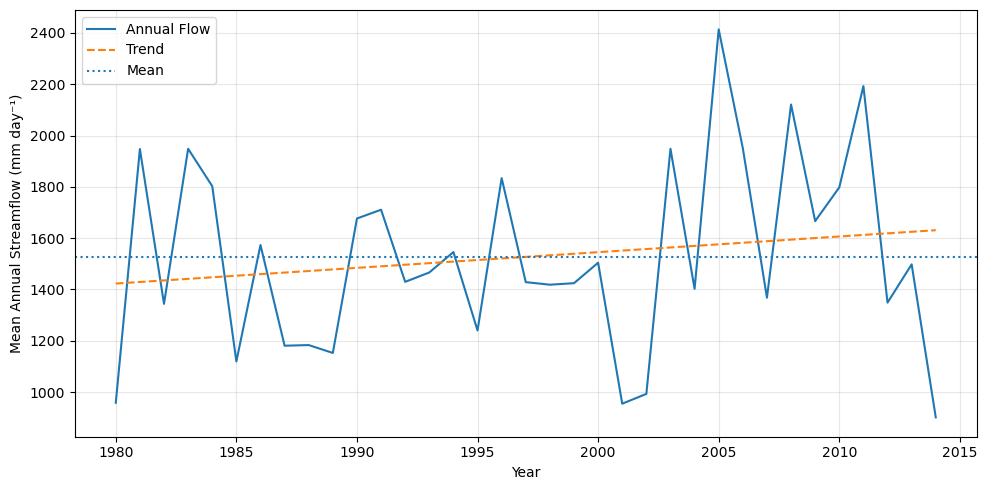

In [5]:
import numpy as np

plt.figure(figsize=(10,5))

# Plotting data

plt.plot(annual_flow.index, annual_flow.values, label="Annual Flow")

# Adding trend lines

z = np.polyfit(annual_flow.index, annual_flow.values, 1)
p = np.poly1d(z)
plt.plot(annual_flow.index, p(annual_flow.index), 
         linestyle="--", 
         label="Trend")

mean_flow = annual_flow.mean()
plt.axhline(mean_flow, linestyle=":", label="Mean")


# Adding axis labels and legend

plt.xlabel("Year")
plt.ylabel("Mean Annual Streamflow (mm day⁻¹)")

plt.legend(loc = "upper left")
plt.grid(alpha = 0.3)

plt.tight_layout()
plt.savefig("figure1_streamflow_improved.png", dpi=300)
plt.show()

In [18]:
# Loading catchment precipitation data

precipitation = pd.read_csv("01013500_lump_cida_forcing_leap.txt", 
                            sep=r"\s+",
                            skiprows=3,
                           engine = "python")

# Adding column labels and a date column

precipitation.columns = [
    "year", "month", "day", "hour", "dayl", "prcp", "srad", "swe",
    "tmax", "tmin", "vp"]
precipitation['date'] = pd.to_datetime(precipitation[['year', 'month', 'day']])

# Annual precipitation variable 

annual_precipitation = precipitation.groupby('year')['prcp'].sum()

# Combining annual streamflow and annual precipitation

prcp_strflw = pd.DataFrame({
    "streamflow": annual_flow,
    "precipitation": annual_precipitation
}).dropna()

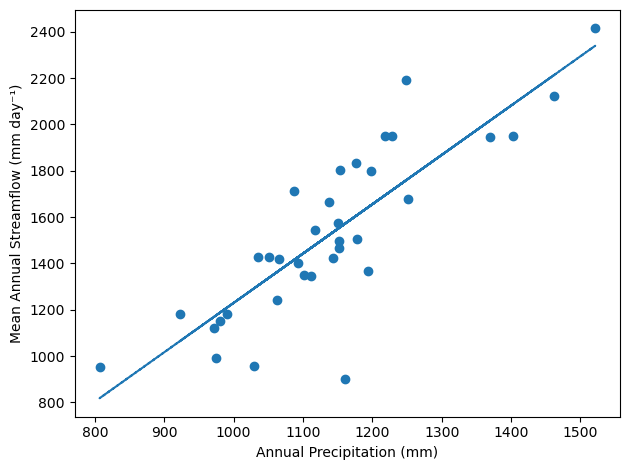

In [38]:
# Plotting data from combined data frame

plt.scatter(prcp_strflw['precipitation'], prcp_strflw['streamflow'])

# Adding a trend line

z = np.polyfit(prcp_strflw['precipitation'], 
               prcp_strflw['streamflow'], 1)
p = np.poly1d(z)
plt.plot(prcp_strflw['precipitation'], p(prcp_strflw['precipitation']),
        linestyle = "--")

# Adding axes labels and legend 

plt.xlabel("Annual Precipitation (mm)")
plt.ylabel("Mean Annual Streamflow (mm day⁻¹)")
plt.tight_layout()

plt.savefig("figure2_prcp_vs_strflw.png", dpi=300)
plt.show()

In [36]:
# Calculating R-squared

r = np.corrcoef(prcp_strflw['precipitation'], prcp_strflw['streamflow'])[0, 1]
r2 = r**2

print("R² =", r2)

R² = 0.7017423664988788
